# Tapia Figures
Replicates Fig 2.12 (Corporate Profits), Fig 2.15 (World GDP Growth), and Capital Cycle plots from Tapia (2023).

**Prerequisite:** run `python -m src.benchmarks.finance.pipeline` from the repo root to populate `data/processed/`.

In [1]:
# ── FLAGS ──────────────────────────────────────────────
SAVE_FIGS = True
# ───────────────────────────────────────────────────────

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from pathlib import Path

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

DATA_DIR = Path('../data/processed')
OUT_DIR = Path('../output/notebooks')
if SAVE_FIGS:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

## Fig 2.12 — Corporate Profits Before & After Tax

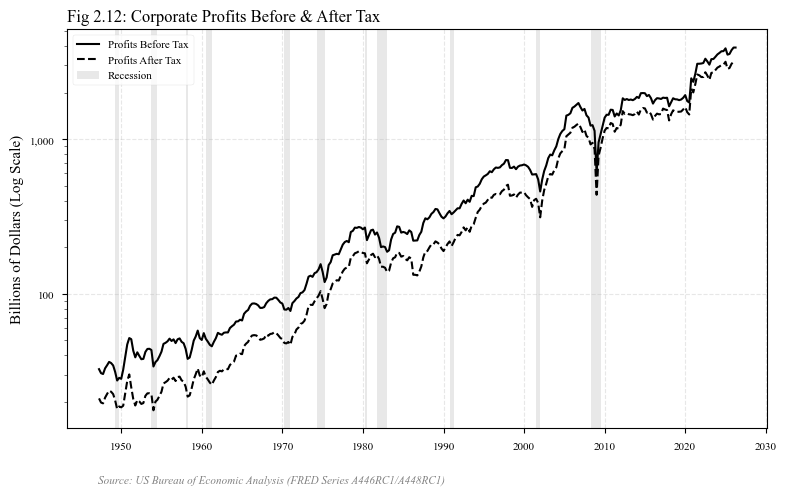

In [3]:
df = pd.read_csv(DATA_DIR / 'corporate_profits.csv', index_col=0, parse_dates=True)

fig, ax = plt.subplots()
ax.plot(df.index, df['PROFITS_BEFORE_TAX'], color='black', lw=1.5, label='Profits Before Tax')
ax.plot(df.index, df['PROFITS_AFTER_TAX'], color='black', lw=1.5, ls='--', label='Profits After Tax')

if 'RECESSION' in df.columns:
    ax.fill_between(df.index, 0, 1, where=df['RECESSION'] > 0.5,
                    transform=ax.get_xaxis_transform(), color='#d3d3d3', alpha=0.5, lw=0, label='Recession')

ax.set_yscale('log')
ax.set_ylabel('Billions of Dollars (Log Scale)')
ax.set_title('Fig 2.12: Corporate Profits Before & After Tax', loc='left')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: '{:,.0f}'.format(y)))
fig.text(0.13, 0.02, 'Source: US Bureau of Economic Analysis (FRED Series A446RC1/A448RC1)',
         fontsize=8, color='gray', style='italic')
plt.legend(loc='upper left')
plt.tight_layout(rect=[0, 0.05, 1, 1])

if SAVE_FIGS:
    plt.savefig(OUT_DIR / 'fig2_12_corporate_profits.png', dpi=300, bbox_inches='tight')
plt.show()

## Fig 2.15 — World GDP per Capita Growth

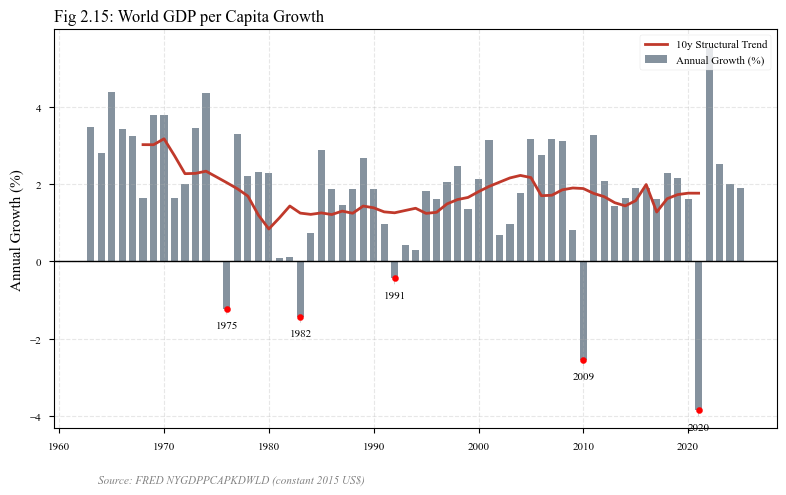

In [4]:
df = pd.read_csv(DATA_DIR / 'global_growth.csv', index_col=0, parse_dates=True)
df['Growth'] = df['WGDP_PC_LEVEL'].pct_change() * 100
df = df.dropna()
df['Trend'] = df['Growth'].rolling(window=10, center=True).mean()

fig, ax = plt.subplots()
ax.bar(df.index, df['Growth'], color='#34495e', alpha=0.6, width=250, label='Annual Growth (%)')
ax.plot(df.index, df['Trend'], color='#c0392b', lw=2, label='10y Structural Trend')
ax.axhline(0, color='black', linewidth=1)

contractions = df[df['Growth'] < 0]
if not contractions.empty:
    ax.scatter(contractions.index, contractions['Growth'], color='red', s=20, zorder=5)
    for row in contractions.itertuples():
        ax.annotate(f'{row.Index.year}', xy=(row.Index, row.Growth),
                    xytext=(row.Index, row.Growth - 0.5), ha='center', fontsize=8,
                    arrowprops=dict(arrowstyle='-', color='gray'))

ax.set_title('Fig 2.15: World GDP per Capita Growth', loc='left')
ax.set_ylabel('Annual Growth (%)')
fig.text(0.13, 0.02, 'Source: FRED NYGDPPCAPKDWLD (constant 2015 US$)',
         fontsize=8, color='gray', style='italic')
plt.legend(loc='upper right', frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])

if SAVE_FIGS:
    plt.savefig(OUT_DIR / 'fig2_15_global_growth.png', dpi=300, bbox_inches='tight')
plt.show()

## Capital Cycle — Investment/GDP & Inventory

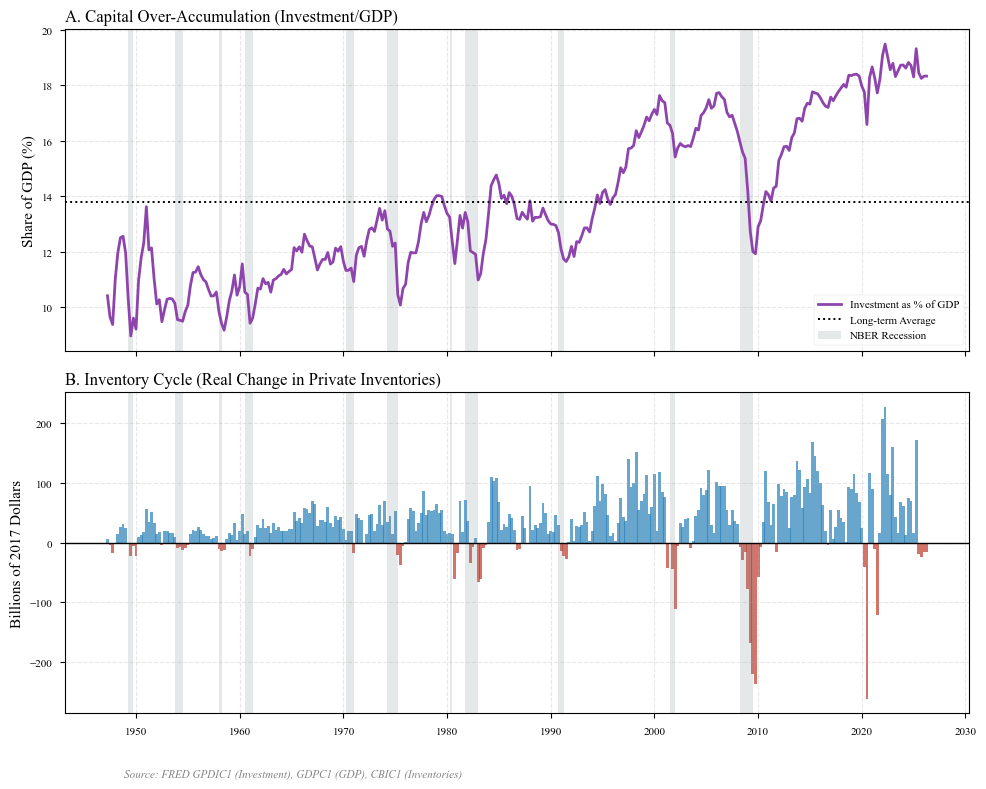

In [5]:
df = pd.read_csv(DATA_DIR / 'capital_cycle.csv', index_col=0, parse_dates=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

if 'REAL_INVESTMENT' in df.columns and 'REAL_GDP' in df.columns:
    df['Inv_Ratio'] = (df['REAL_INVESTMENT'] / df['REAL_GDP']) * 100
    ax1.plot(df.index, df['Inv_Ratio'], color='#8e44ad', lw=2, label='Investment as % of GDP')
    ax1.axhline(df['Inv_Ratio'].mean(), color='black', ls=':', label='Long-term Average')
    ax1.set_title('A. Capital Over-Accumulation (Investment/GDP)', loc='left')
    ax1.set_ylabel('Share of GDP (%)')

if 'RECESSION' in df.columns:
    ax1.fill_between(df.index, 0, 1, where=df['RECESSION'] > 0.5,
                     transform=ax1.get_xaxis_transform(), color='#7f8c8d', alpha=0.2, lw=0, label='NBER Recession')
ax1.legend(loc='lower right')

if 'REAL_INVENTORY_CHANGE' in df.columns:
    colors = np.where(df['REAL_INVENTORY_CHANGE'] >= 0, '#2980b9', '#c0392b')
    ax2.bar(df.index, df['REAL_INVENTORY_CHANGE'], color=colors, width=100, alpha=0.7)
    ax2.axhline(0, color='black', lw=1)
    ax2.set_title('B. Inventory Cycle (Real Change in Private Inventories)', loc='left')
    ax2.set_ylabel('Billions of 2017 Dollars')

if 'RECESSION' in df.columns:
    ax2.fill_between(df.index, 0, 1, where=df['RECESSION'] > 0.5,
                     transform=ax2.get_xaxis_transform(), color='#7f8c8d', alpha=0.2, lw=0)

fig.text(0.13, 0.02, 'Source: FRED GPDIC1 (Investment), GDPC1 (GDP), CBIC1 (Inventories)',
         fontsize=8, color='gray', style='italic')
plt.tight_layout(rect=[0, 0.05, 1, 1])

if SAVE_FIGS:
    plt.savefig(OUT_DIR / 'fig_capital_inventory_cycle.png', dpi=300, bbox_inches='tight')
plt.show()